# Visualização Inicial
Notebook responsável pela visualização inicial dos dados em `/data/processed/expired_items_dataset_processed.csv`.

---
# 1. Importando Bibliotecas

Bibliotecas utilizadas para manipulação, visualização de dados e controle de avisos.

In [1]:
# bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

---
# 2. Atribuindo a Base de Dados para DataFrame 


In [2]:
# importando dataset

df = pd.read_csv(
    '../data/processed/expired_items_dataset_processed.csv'
)

---
# 3. Validação Final

Importante manter o arquivo de limpeza aberto nessa etapa para confirmar diferenças.

In [3]:
# covertendo novamente colunas para datetime

for col in ['DATA', 'VALIDADE']:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

Colunas convertidas novamente para manipular os dados nesse notebook.

Conversão definitiva será feita em SQL. 

In [4]:
# confirma dimensões 
df.shape

(28006, 6)

In [5]:
# retorna a qnts de valores unicos em cada coluna + lista o nome das colunas

df.nunique()

DATA           919
BANDEIRA         2
LOJA            23
QUANTIDADE     212
SETOR           18
VALIDADE      1588
dtype: int64

In [6]:
# verifica se há datas de validade maiores que data de vistoria

df[df['VALIDADE']>df['DATA']] 

,DATA,BANDEIRA,LOJA,QUANTIDADE,SETOR,VALIDADE


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28006 entries, 0 to 28005
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DATA        28006 non-null  datetime64[ns]
 1   BANDEIRA    28006 non-null  object        
 2   LOJA        28006 non-null  int64         
 3   QUANTIDADE  28006 non-null  int64         
 4   SETOR       28006 non-null  object        
 5   VALIDADE    28006 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(2)
memory usage: 1.3+ MB


In [8]:
# confere visualmente se os dados apresentam problemas

df.head()

,DATA,BANDEIRA,LOJA,QUANTIDADE,SETOR,VALIDADE
0,2022-01-03,JOAO,16,1,MERCEARIA COMPLEMENTAR,2021-10-20
1,2022-01-03,JOAO,16,4,MERCEARIA COMPLEMENTAR,2022-01-01
2,2022-01-03,JOAO,16,1,MERCEARIA COMPLEMENTAR,2021-12-01
3,2022-01-03,JOAO,16,2,MERCEARIA COMPLEMENTAR,2022-01-01
4,2022-01-03,JOAO,16,3,MERCEARIA COMPLEMENTAR,2021-04-30


Validações concluídas, nenhum erro identificado.

DataFrame consistente e pronto para visualizações.

---
# 4. Visualizações

## 4.1 Padronização dos gráficos

In [9]:
# criando padrao visual dos graficos

plt.rcParams.update({
    # layout
    'figure.figsize': (8,4), 
    'figure.constrained_layout.use': True,

    # cor padrão
    'axes.prop_cycle': plt.cycler(color=["#465470"]),

    # titulo
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#505050',

    # eixos 
    'axes.labelcolor':'#7C7C7C',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'xtick.color': '#7C7C7C',
    'ytick.color': '#7C7C7C',

    # grid
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'axes.axisbelow': True,

    # bordas
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
})

Configuração global de estilo dos gráficos via `rcParams` para manter consistência visual.

## 4.2 Ocorrências totais por Bandeira

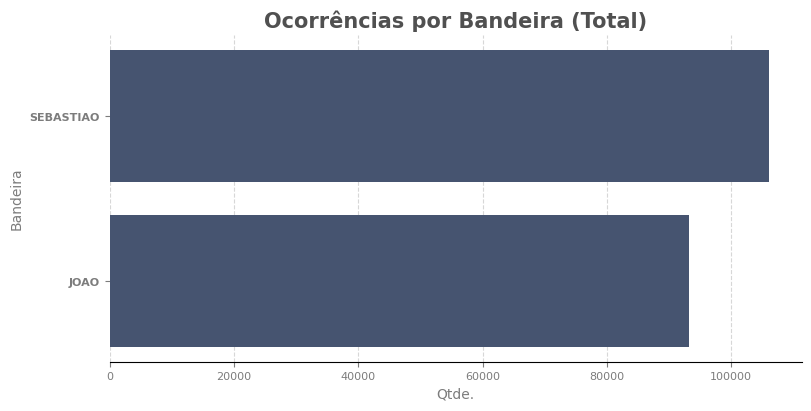

In [10]:
qntd = df.groupby('BANDEIRA')['QUANTIDADE'].sum()       # define valores do grafico

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.barh(                                                 # grafico
    qntd.index,
    qntd.values
)
ax.set(
    title='Ocorrências por Bandeira (Total)',         # titulo
    xlabel='Qtde.',                                 # titulo eixo x
    ylabel='Bandeira'                             # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                              # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

A bandeira SEBASTIAO apresenta maior quantidade de itens vencidos encontrados no período analisado em comparação com a bandeira JOAO.

## 4.3 Top 10 Setores com mais ocorrências

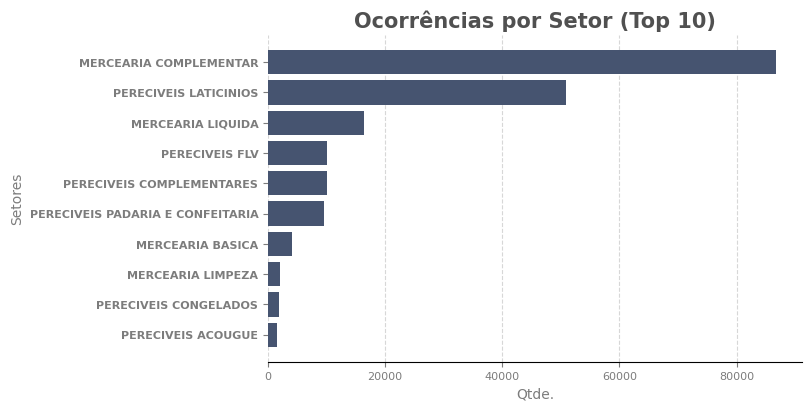

In [11]:
top10 = (                                              # define valores do grafico
    df.groupby('SETOR')['QUANTIDADE']
    .sum()
    .nlargest(10,'all')
    .sort_values()   
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.barh(                                                # grafico
    top10.index,
    top10.values
)
ax.set(
    title='Ocorrências por Setor (Top 10)',             # titulo
    xlabel='Qtde.',                                     # titulo eixo x
    ylabel='Setores'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

A quantidade de itens vencidos nos primeiros dois setores (MERCEARIA COMPLEMENTAR e PERECIVEIS LATICINIOS) chama a atenção pela distribuição se comparado a outros setores. 

## 4.4 Ocorrências totais por Loja

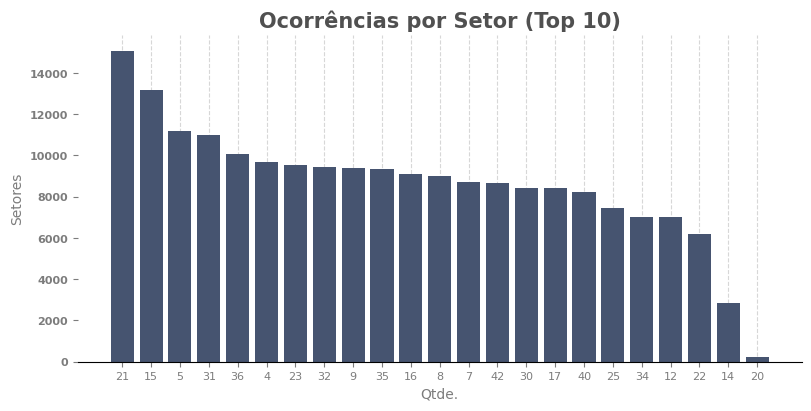

In [12]:
qntd = (                                              # define valores do grafico
    df.groupby('LOJA')['QUANTIDADE']
    .sum()
    .sort_values(ascending=False)   
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 

ax.bar(                                                # grafico
    qntd.index.astype(str),
    qntd.values
)
ax.set(
    title='Ocorrências por Setor (Top 10)',             # titulo
    xlabel='Qtde.',                                     # titulo eixo x
    ylabel='Setores'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

É notável uma boa distribuição entre as lojas, com exceção da loja 20 que registra uma quantidade significativamente inferior às demais.

## 4.5 Ocorrências totais ao longo do Tempo

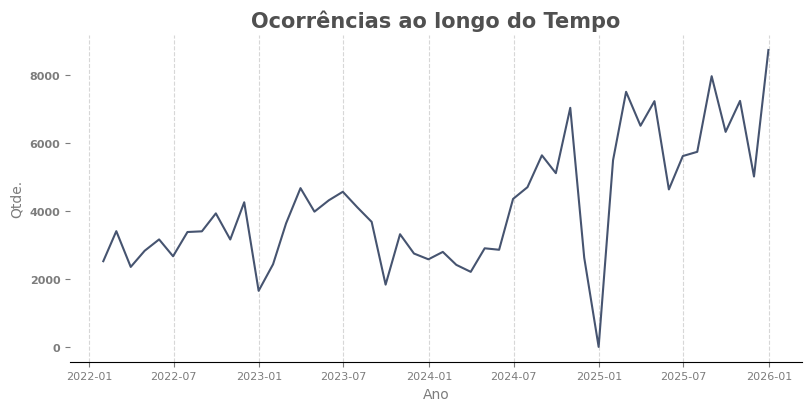

In [13]:
qntd = (                                              # define valores do grafico
    df.set_index('DATA')['QUANTIDADE']
    .resample('M')
    .sum()
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 


ax.plot(                                                # grafico
    qntd.index,
    qntd.values
)
ax.set(
    title='Ocorrências ao longo do Tempo',             # titulo
    xlabel='Ano',                                     # titulo eixo x
    ylabel='Qtde.'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

Em Dezembro de 2024 é possivel observar números consideravelmente abaixo dos demais, destacando um período de maior zelo aos itens a vencer, contrastando com dezembro de 2025 que demonstra alta histórica.  

## 4.6 Validades Expiradas

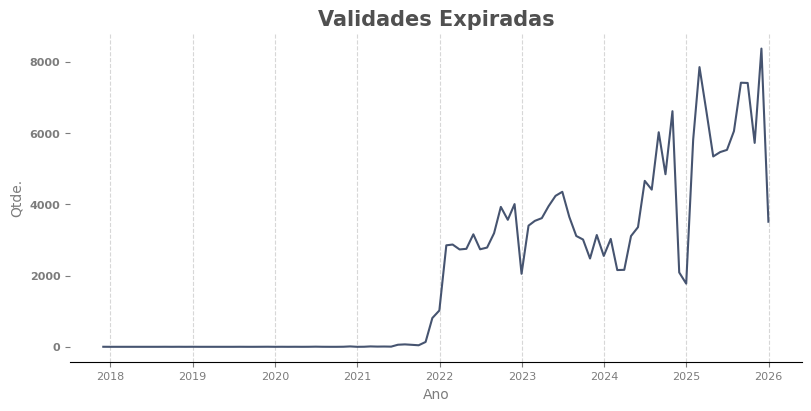

In [14]:
qntd = (                                              # define valores do grafico
    df.set_index('VALIDADE')['QUANTIDADE']
    .resample('M')
    .sum()
)

fig, ax = plt.subplots()                                # var para definir parametros especificos do graf 


ax.plot(                                                # grafico
    qntd.index,
    qntd.values
)
ax.set(
    title='Validades Expiradas',             # titulo
    xlabel='Ano',                                     # titulo eixo x
    ylabel='Qtde.'                                    # titulo eixo y
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontweight = 'bold'                                 # fonte negrito info eixo y
)

ax.grid(False)                                         # desliga grid global
ax.grid(axis='x')                                      # define grid local em x


plt.show()

A conferência externa se iniciou em 2022 mas notamos que foram achados itens desde 2017.

Apesar da baixa quantidade é um ponto a ser destacado para as equipes de controle interno.

## 4.6 Tabela Total de itens por Ano e Bandeira

In [16]:
# coluna ano

df['ANO'] = df['DATA'].dt.year

# criação de tabela ano x bandeira x total
table = (
    df.groupby(['ANO', 'BANDEIRA'])
    .agg(
        TOTAL_ITENS = ('QUANTIDADE', 'sum')
    )
)

# visualização da tabela

table

TOTAL_ITENS
ANO  BANDEIRA              
2022 JOAO             20153
     SEBASTIAO        16545
2023 JOAO             21981
     SEBASTIAO        19859
2024 JOAO             18424
     SEBASTIAO        24198
2025 JOAO             32562
     SEBASTIAO        45419

Apesar de algumas quedas ao longo do período analisado, a tendência geral indica aumento nas ocorrências, o contrário do esperado.

---
# 6. Conclusão 

A etapa de validação final confirmou a integridade e a consistência dos dados, reduzindo o risco de inconsistências nas etapas posteriores do projeto.

A visualização exploratória inicial permitiu avaliar a coerência das informações, identificar padrões e responder questionamentos fundamentais gerando insights que auxiliam na criação de dashboard futuro.

Principais insights:
* A bandeira SEBASTIAO toma a frente na quantidade de itens vencidos.
* O setor MERCEARIA COMPLEMENTAR é o mais prejudicial para as lojas. 
* É necessário a investigação do número inferior ao padrão apresentado pela loja 20.
* Dezembro de 2025 teve destaque na quantidade de itens vencidos, destoando da média geral.
* Itens encontrados cerca de 5 anos antes da vistoria externa pode representar má administração do controle de validade.
* Crescimento das ocorrências ao longo dos anos mesmo com duas equipes (interna e externa) fiscalizando validades.


